# ADMM solve — time-resolved (GMD × stage z)

Same regularised inversion as `admm_solve.ipynb`, but applied to the
*time-resolved* aggregates: the eTOF dimension is reduced to a single
scalar (the hit count inside a TOF ROI), and shots are additionally
binned by stage position `z`. Per (GMD, z) bin we solve

    min_x  ½||M x - b||²  +  ½ λ_p ||D_p x||²  +  λ_s ||x||₁

with `M = Cov(A)` (n_pixels × n_pixels), `b = Cov(A, D)` (n_pixels × 1).
The result `x*` is a 1D spectral response (n_pixels values) for every
(GMD bin, stage position) — the dependence on `z` is the time-resolved
signal.

In [1]:
import sys
from pathlib import Path
_REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(_REPO_ROOT / "analysis" / "scripts"))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

import config
from compute_aggregates import load_aggregates
from admm_ghost import solve_admm

%matplotlib inline

## Parameters

In [2]:
AGGREGATES_FILE = config.COMBINED_DIR / "test_config2_aggregates_tr.h5"

# Bin to inspect in detail.
FOCUS_GMD = 3

# Regularisation. No TOF axis to smooth → lambda_smooth_tof = 0.
LAMBDA_SMOOTH_PIXEL = 1e3
LAMBDA_SMOOTH_TOF   = 0.0
LAMBDA_SPARSE       = 5e-2

RHO        = 1e4
MAX_ITER   = 500
DIFF_ORDER = 2
TOL        = 1e-4

CLIM_PERCENTILE = 99.0

## Load TR aggregates

In [3]:
agg = load_aggregates(AGGREGATES_FILE)
assert agg.mode == "time_resolved", "This notebook expects a time-resolved aggregates file."

print(f"file        : {AGGREGATES_FILE}")
print(f"mode        : {agg.mode}")
print(f"n_pixels    : {agg.n_pixels}")
print(f"n_gmd_bins  : {agg.n_gmd_bins}")
print(f"n_z_bins    : {agg.n_z_bins}")
print(f"TOF ROI     : {agg.tof_edges}")
print(f"GMD edges   : {agg.gmd_edges}")
print(f"z range     : [{agg.z_edges[0]:.0f}, {agg.z_edges[-1]:.0f}]  ({agg.n_z_bins} bins)")
print(f"shots total : {int(agg.n_per_bin.sum())}")
print(f"shots/bin per GMD (summed over z): {agg.n_per_bin.sum(axis=1)}")

file        : C:\Users\oga17\OneDrive - Imperial College London\Python\glycine2026\11022188\processed\combined\test_config2_aggregates_tr.h5
mode        : time_resolved
n_pixels    : 120
n_gmd_bins  : 7
n_z_bins    : 20
TOF ROI     : [ 800. 1200.]
GMD edges   : [0.   0.05 0.1  0.2  0.4  0.8  1.5  3.  ]
z range     : [-15000, 16500]  (20 bins)
shots total : 426402
shots/bin per GMD (summed over z): [ 68585  60043  93019 112154  71552  19290   1759]


## Form per-bin covariances

Vectorised across (GMD, z): `Cov(A) = <AtA> − <A><A>ᵀ` and
`Cov(A, D) = <AtD> − <A><D>ᵀ`. Resulting shapes:

    cov_AA  (N_GMD, N_Z, n_pixels, n_pixels)
    cov_AD  (N_GMD, N_Z, n_pixels, 1)

In [4]:
cov_AA = agg.AtA - agg.A[..., :, None] * agg.A[..., None, :]
cov_AD = agg.AtD - agg.A[..., :, None] * agg.D[..., None, :]

print(f"cov_AA shape: {cov_AA.shape}")
print(f"cov_AD shape: {cov_AD.shape}")

cov_AA shape: (7, 20, 120, 120)
cov_AD shape: (7, 20, 120, 1)


## Solve for every (GMD, z) bin

Each call has B of shape `(n_pixels, 1)`. With `lambda_smooth_tof = 0`
and a singleton TOF axis the solver reduces to a 1D inversion under
pixel smoothness + sparsity.

In [5]:
X_grid = np.full((agg.n_gmd_bins, agg.n_z_bins, agg.n_pixels), np.nan)
summary = []

for g in range(agg.n_gmd_bins):
    for z in range(agg.n_z_bins):
        n = int(agg.n_per_bin[g, z])
        if n == 0 or not np.isfinite(cov_AD[g, z]).all():
            continue
        M = cov_AA[g, z]                    # (n_pixels, n_pixels)
        B = cov_AD[g, z]                    # (n_pixels, 1)
        r = solve_admm(
            M, B,
            lambda_smooth_pixel=LAMBDA_SMOOTH_PIXEL,
            lambda_smooth_tof=LAMBDA_SMOOTH_TOF,
            lambda_sparse=LAMBDA_SPARSE,
            rho=RHO,
            diff_order=DIFF_ORDER,
            max_iter=MAX_ITER,
            tol_primal=TOL, tol_dual=TOL,
            track_objective=False,
        )
        X_grid[g, z] = r.X[:, 0]
        summary.append((g, z, n, float(np.linalg.norm(r.X)), r.n_iter, r.converged))

n_converged = sum(1 for *_, cv in summary if cv)
print(f"solved {len(summary)} bins ({n_converged} converged)")
print()
print(f"per-GMD: mean |X|, mean iters, converged frac")
for g in range(agg.n_gmd_bins):
    rows = [s for s in summary if s[0] == g]
    if not rows:
        print(f"  bin {g}: (empty)")
        continue
    mean_norm = float(np.mean([r[3] for r in rows]))
    mean_it   = float(np.mean([r[4] for r in rows]))
    cv_frac   = float(np.mean([r[5] for r in rows]))
    print(f"  bin {g}  GMD [{agg.gmd_edges[g]:.3f}, {agg.gmd_edges[g+1]:.3f}): "
          f"|X|~{mean_norm:.2e}  iters~{mean_it:.0f}  conv={cv_frac:.0%}")

solved 140 bins (133 converged)

per-GMD: mean |X|, mean iters, converged frac
  bin 0  GMD [0.000, 0.050): |X|~7.18e-03  iters~9  conv=100%
  bin 1  GMD [0.050, 0.100): |X|~7.83e-03  iters~9  conv=100%
  bin 2  GMD [0.100, 0.200): |X|~6.46e-03  iters~9  conv=100%
  bin 3  GMD [0.200, 0.400): |X|~6.15e-03  iters~8  conv=100%
  bin 4  GMD [0.400, 0.800): |X|~8.08e-03  iters~9  conv=100%
  bin 5  GMD [0.800, 1.500): |X|~1.74e-02  iters~10  conv=100%
  bin 6  GMD [1.500, 3.000): |X|~7.33e-02  iters~260  conv=65%


## X*(pixel, z) per GMD bin

Each panel: rows = VLS pixel, columns = stage position. Shows how the
spectral response shifts / changes amplitude as a function of `z`.

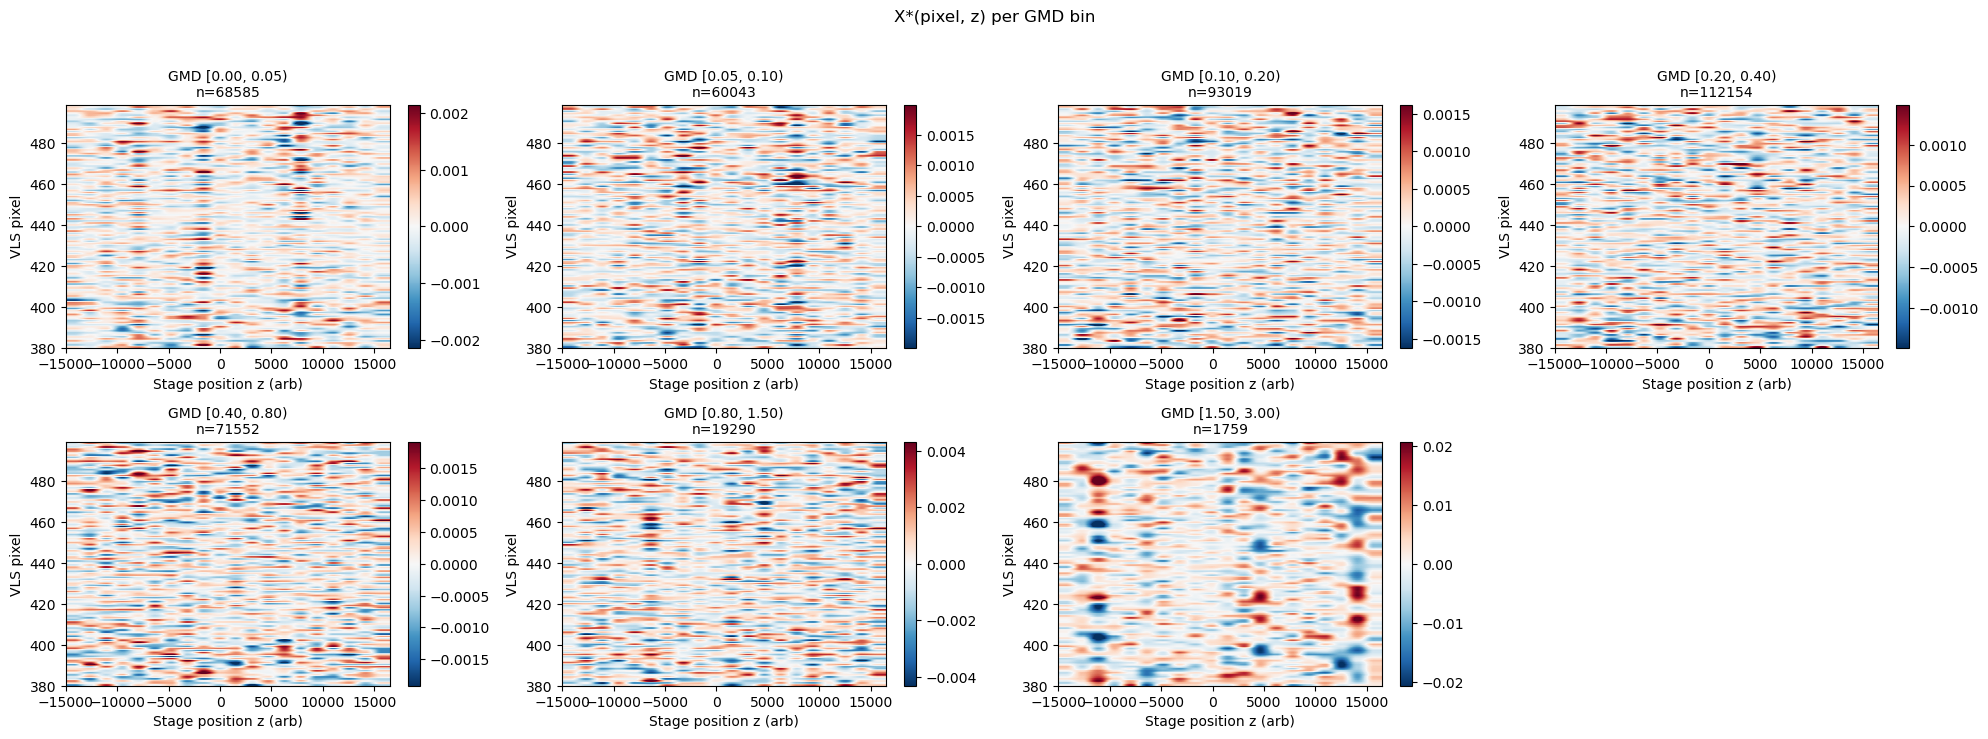

In [6]:
n = agg.n_gmd_bins
cols = min(4, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5.0 * cols, 3.6 * rows))
axes_flat = np.atleast_1d(axes).ravel()

extent = [agg.z_edges[0], agg.z_edges[-1],
          agg.vls_pixels[0], agg.vls_pixels[-1]]

for g in range(n):
    ax = axes_flat[g]
    panel = X_grid[g].T            # (n_pixels, n_z)
    if not np.isfinite(panel).any():
        ax.set_title(f"bin {g}  (empty)")
        ax.axis("off")
        continue
    vmax = float(np.nanpercentile(np.abs(panel), CLIM_PERCENTILE))
    if vmax == 0:
        vmax = float(np.nanmax(np.abs(panel))) or 1.0
    im = ax.imshow(panel, origin="lower", cmap="RdBu_r",
                   vmin=-vmax, vmax=vmax, extent=extent, aspect="auto")
    ax.set_xlabel("Stage position z (arb)")
    ax.set_ylabel("VLS pixel")
    n_g = int(agg.n_per_bin[g].sum())
    ax.set_title(f"GMD [{agg.gmd_edges[g]:.2f}, {agg.gmd_edges[g+1]:.2f})\n"
                 f"n={n_g}", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046)

for ax in axes_flat[n:]:
    ax.axis("off")

fig.suptitle("X*(pixel, z) per GMD bin", y=1.02)
fig.tight_layout()
plt.show()

## Scalar response vs stage position

Two summaries of the per-bin kernel as a function of `z`, one curve
per GMD bin:

  * `||X*(z)||₁` — total response amplitude (sum of |X| over pixels).
  * `X*(z)` integrated over pixels — net signed response.

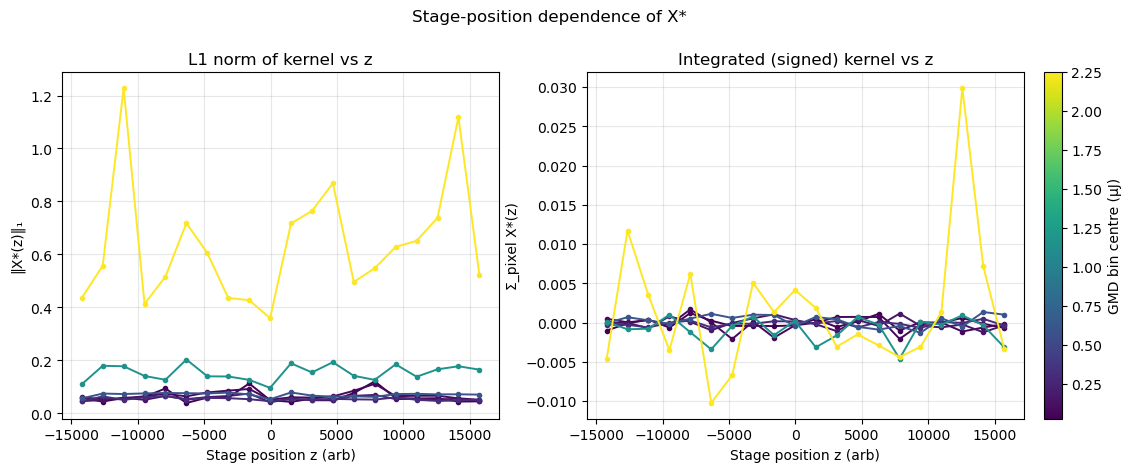

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

cmap = plt.cm.viridis
z_c = agg.z_centres
gmd_c = agg.gmd_centres
norm = Normalize(vmin=float(gmd_c[0]), vmax=float(gmd_c[-1]))

for g in range(agg.n_gmd_bins):
    if not np.isfinite(X_grid[g]).any():
        continue
    colour = cmap(norm(float(gmd_c[g])))
    l1_vs_z  = np.nansum(np.abs(X_grid[g]), axis=1)
    sum_vs_z = np.nansum(X_grid[g], axis=1)
    ax1.plot(z_c, l1_vs_z,  color=colour, lw=1.4, marker="o", ms=3)
    ax2.plot(z_c, sum_vs_z, color=colour, lw=1.4, marker="o", ms=3)

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=[ax1, ax2], label="GMD bin centre (\u00b5J)", fraction=0.025, pad=0.02)

for ax, label in [(ax1, "\u2016X*(z)\u2016\u2081"),
                  (ax2, "\u03a3_pixel X*(z)")]:
    ax.set_xlabel("Stage position z (arb)")
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)

ax1.set_title("L1 norm of kernel vs z")
ax2.set_title("Integrated (signed) kernel vs z")
fig.suptitle("Stage-position dependence of X*", y=1.02)
plt.show()

## Focus GMD bin: X*(pixel) overlay coloured by z

One line per stage-position bin, coloured by z value.